# 💰 Notebook 02 — Análise de Pedidos e Receita (Olist)

**Objetivo:** Analisar a evolução temporal das vendas, métricas de receita (ticket médio, mediano), comportamento de pagamentos, sazonalidade e taxa de cancelamento.

## 1. Importações e Configurações

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Detecção dinâmica de caminhos para dados e outputs
DATA_DIR = '../data/olist' if os.path.exists('../data/olist') else 'data/olist'
if not os.path.exists(DATA_DIR):
    DATA_DIR = '/home/jorge/Documents/tech-challenge-agentes-ia/data/olist'

OUTPUT_DIR = './outputs' if os.path.exists('./outputs') or os.path.basename(os.getcwd()) == 'notebooks' else 'notebooks/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Diretório de Dados: {os.path.abspath(DATA_DIR)}")
print(f"📁 Diretório de Outputs: {os.path.abspath(OUTPUT_DIR)}")


📁 Diretório de Dados: /home/jorge/Documents/tech-challenge-agentes-ia/data/olist
📁 Diretório de Outputs: /home/jorge/Documents/tech-challenge-agentes-ia/notebooks/outputs


## 2. Carregamento e Cruzamento de Dados

In [2]:
orders = pd.read_csv(os.path.join(DATA_DIR, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_payments_dataset.csv'))
products = pd.read_csv(os.path.join(DATA_DIR, 'olist_products_dataset.csv'))
trans = pd.read_csv(os.path.join(DATA_DIR, 'product_category_name_translation.csv'))

# Converter datas
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Merges para análise completa
items_prod = items.merge(products, on='product_id', how='left').merge(trans, on='product_category_name', how='left')
df_full = orders.merge(items_prod, on='order_id', how='left')
print(f"✓ Shape total unificado: {df_full.shape}")


✓ Shape total unificado: (113425, 23)


## 3. Análise Temporal e Sazonalidade

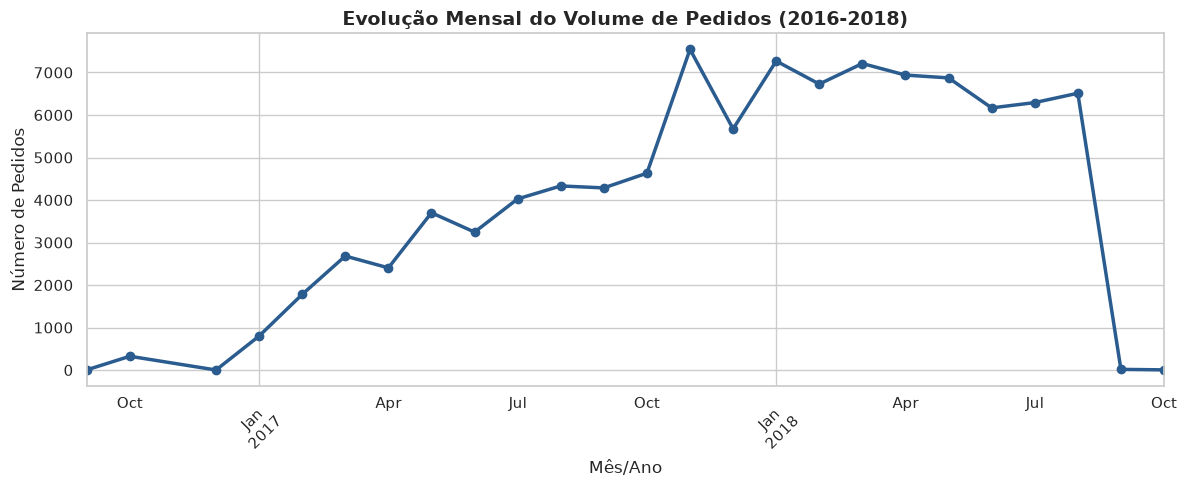

In [3]:
# Criar colunas temporais
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['day_name'] = orders['order_purchase_timestamp'].dt.day_name()
orders['hour_of_day'] = orders['order_purchase_timestamp'].dt.hour

monthly_orders = orders.groupby('year_month').size()

plt.figure(figsize=(12, 5))
monthly_orders.plot(kind='line', marker='o', color='#2b5c8f', linewidth=2.5)
plt.title('Evolução Mensal do Volume de Pedidos (2016-2018)', fontsize=14, fontweight='bold')
plt.xlabel('Mês/Ano')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_evolucao_mensal.png'))
plt.show()


/run/user/1000/snap.antigravity/ipykernel_43738/447257938.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=orders, x='day_name', order=order_days, ax=axes[0], palette='Blues_d')
/run/user/1000/snap.antigravity/ipykernel_43738/447257938.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=orders, x='hour_of_day', ax=axes[1], palette='magma')


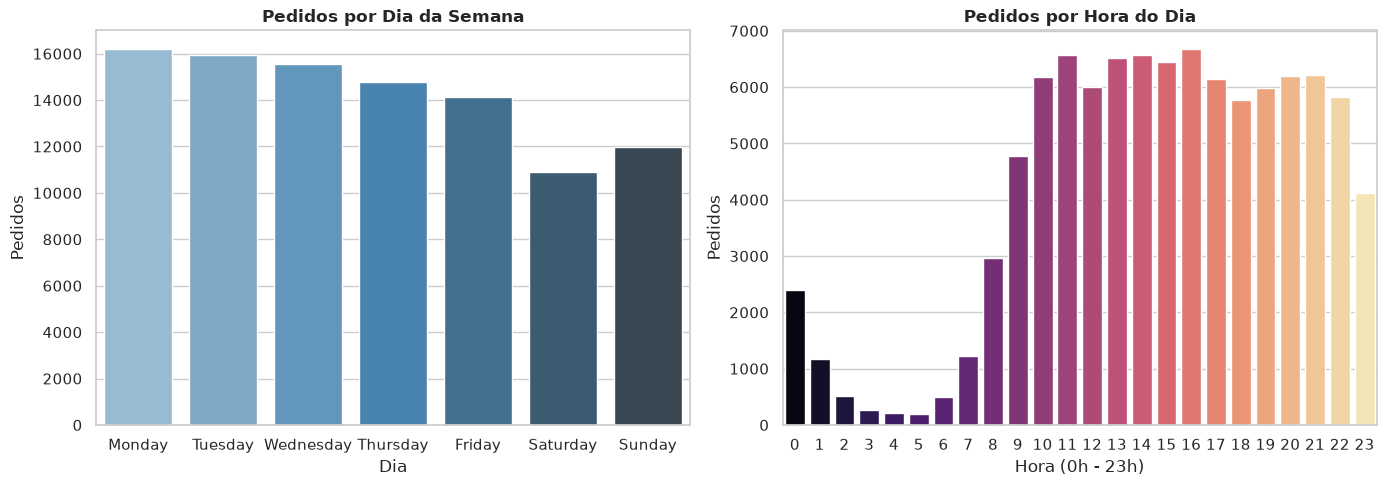

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=orders, x='day_name', order=order_days, ax=axes[0], palette='Blues_d')
axes[0].set_title('Pedidos por Dia da Semana', fontweight='bold')
axes[0].set_xlabel('Dia')
axes[0].set_ylabel('Pedidos')

sns.countplot(data=orders, x='hour_of_day', ax=axes[1], palette='magma')
axes[1].set_title('Pedidos por Hora do Dia', fontweight='bold')
axes[1].set_xlabel('Hora (0h - 23h)')
axes[1].set_ylabel('Pedidos')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_pedidos_por_dia_semana.png'))
plt.show()


## 4. Métricas Financeiras e Receita

In [5]:
total_revenue = items['price'].sum()
total_freight = items['freight_value'].sum()
grand_total = total_revenue + total_freight

order_value = items.groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum'
})
order_value['total'] = order_value['price'] + order_value['freight_value']

avg_ticket = order_value['total'].mean()
median_ticket = order_value['total'].median()
freight_pct = (total_freight / grand_total) * 100

print(f"💵 Receita Total (Itens): R$ {total_revenue:,.2f}")
print(f"🚚 Valor Total de Frete: R$ {total_freight:,.2f}")
print(f"🛍️ Receita Bruta Total: R$ {grand_total:,.2f}")
print(f"📊 Ticket Médio por Pedido: R$ {avg_ticket:.2f}")
print(f"📊 Ticket Mediano por Pedido: R$ {median_ticket:.2f}")
print(f"🚚 Frete Médio como % da Receita Bruta: {freight_pct:.2f}%")


💵 Receita Total (Itens): R$ 13,591,643.70
🚚 Valor Total de Frete: R$ 2,251,909.54
🛍️ Receita Bruta Total: R$ 15,843,553.24
📊 Ticket Médio por Pedido: R$ 160.58
📊 Ticket Mediano por Pedido: R$ 105.29
🚚 Frete Médio como % da Receita Bruta: 14.21%


/run/user/1000/snap.antigravity/ipykernel_43738/240816328.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_rev.values, y=cat_rev.index, palette='viridis')


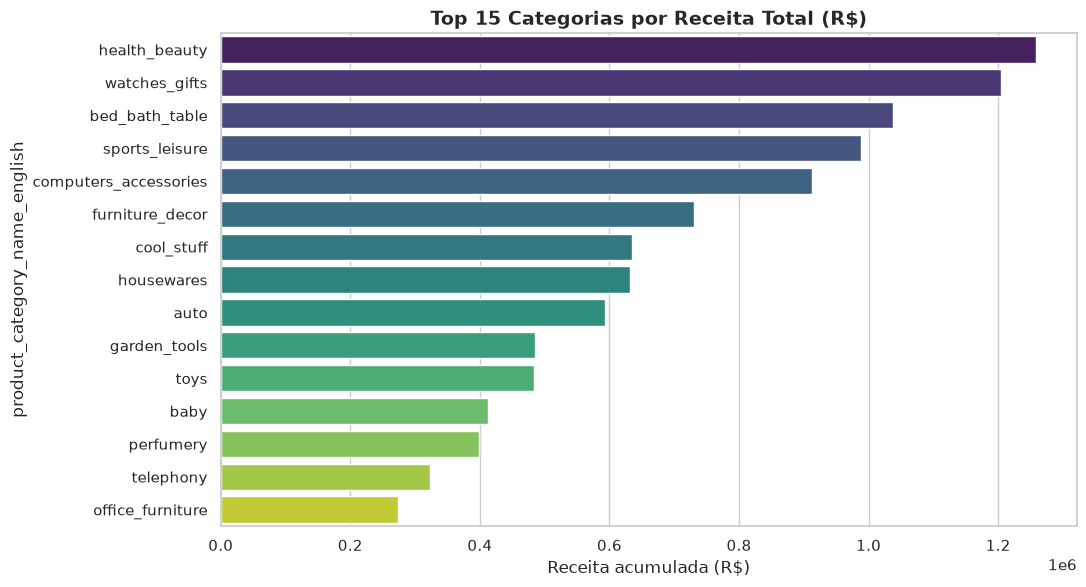

In [6]:
# Top 15 Categorias por Receita
cat_rev = items_prod.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(11, 6))
sns.barplot(x=cat_rev.values, y=cat_rev.index, palette='viridis')
plt.title('Top 15 Categorias por Receita Total (R$)', fontsize=14, fontweight='bold')
plt.xlabel('Receita acumulada (R$)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_receita_por_categoria.png'))
plt.show()


## 5. Análise de Pagamentos e Parcelamento

In [7]:
pmt_summary = payments.groupby('payment_type').agg(
    transacoes=('payment_value', 'count'),
    valor_total=('payment_value', 'sum'),
    ticket_medio=('payment_value', 'mean'),
    parcelas_medias=('payment_installments', 'mean')
).sort_values(by='valor_total', ascending=False)

display(pmt_summary)


,transacoes,valor_total,ticket_medio,parcelas_medias
payment_type,,,,
credit_card,76795,12542084.19,163.319021,3.507155
boleto,19784,2869361.27,145.034435,1.000000
voucher,5775,379436.87,65.703354,1.000000
debit_card,1529,217989.79,142.570170,1.000000
not_defined,3,0.00,0.000000,1.000000


/run/user/1000/snap.antigravity/ipykernel_43738/2679373779.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=payments[payments['payment_value'] < 1000], x='payment_type', y='payment_value', palette='Set2')


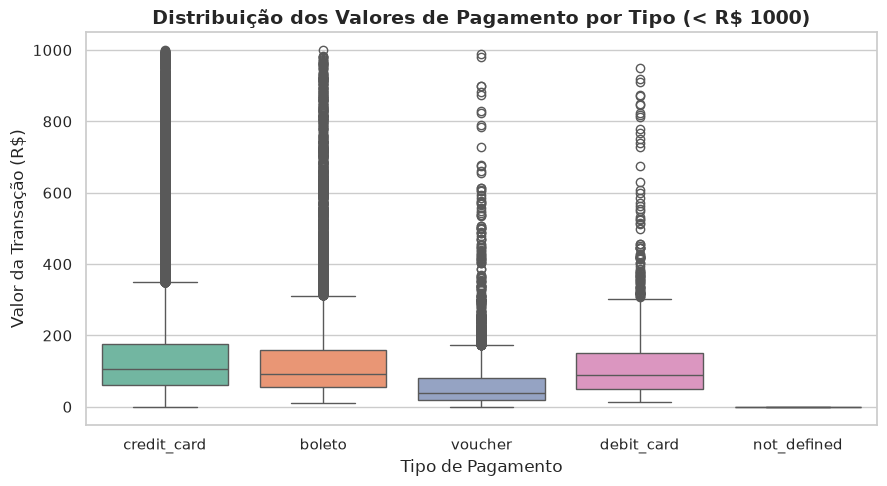

In [8]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=payments[payments['payment_value'] < 1000], x='payment_type', y='payment_value', palette='Set2')
plt.title('Distribuição dos Valores de Pagamento por Tipo (< R$ 1000)', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Pagamento')
plt.ylabel('Valor da Transação (R$)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '08_valor_por_tipo_pagamento.png'))
plt.show()


## 6. Funil de Pedidos e Entregas

In [9]:
status_counts = orders['order_status'].value_counts()
cancel_rate = (status_counts.get('canceled', 0) / len(orders)) * 100

orders_delivered = orders.dropna(subset=['order_delivered_customer_date', 'order_purchase_timestamp']).copy()
orders_delivered['delivery_time_days'] = (orders_delivered['order_delivered_customer_date'] - orders_delivered['order_purchase_timestamp']).dt.total_seconds() / (24*3600)

avg_delivery_time = orders_delivered['delivery_time_days'].mean()
median_delivery_time = orders_delivered['delivery_time_days'].median()

print(f"🚫 Taxa de Cancelamento de Pedidos: {cancel_rate:.2f}%")
print(f"⏱️ Tempo Médio de Entrega: {avg_delivery_time:.2f} dias")
print(f"⏱️ Tempo Mediano de Entrega: {median_delivery_time:.2f} dias")


🚫 Taxa de Cancelamento de Pedidos: 0.63%
⏱️ Tempo Médio de Entrega: 12.56 dias
⏱️ Tempo Mediano de Entrega: 10.22 dias
